In [10]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [11]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Age': np.random.randint(18, 70, n),
    'Annual_Income_k': np.random.randint(15, 150, n),
    'Spending_Score': np.random.randint(1, 100, n),
    'Purchase_Frequency': np.random.randint(1, 50, n),
    'Avg_Order_Value': np.random.randint(20, 500, n),
})

print("✅ Columns:", df.columns.tolist())  # Confirm column names
print("✅ Shape:", df.shape)

✅ Columns: ['CustomerID', 'Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency', 'Avg_Order_Value']
✅ Shape: (200, 6)


       CustomerID        Age  Annual_Income_k  Spending_Score  \
count  200.000000  200.00000       200.000000      200.000000   
mean   100.500000   43.42500        87.500000       49.725000   
std     57.879185   14.94191        39.665308       29.239771   
min      1.000000   18.00000        15.000000        1.000000   
25%     50.750000   31.00000        55.250000       23.750000   
50%    100.500000   43.50000        83.500000       49.000000   
75%    150.250000   56.00000       126.000000       75.000000   
max    200.000000   69.00000       149.000000       99.000000   

       Purchase_Frequency  Avg_Order_Value  
count          200.000000        200.00000  
mean            23.985000        232.93000  
std             14.170348        141.36547  
min              1.000000         20.00000  
25%             12.000000        110.50000  
50%             24.000000        233.00000  
75%             35.000000        346.25000  
max             49.000000        493.00000  


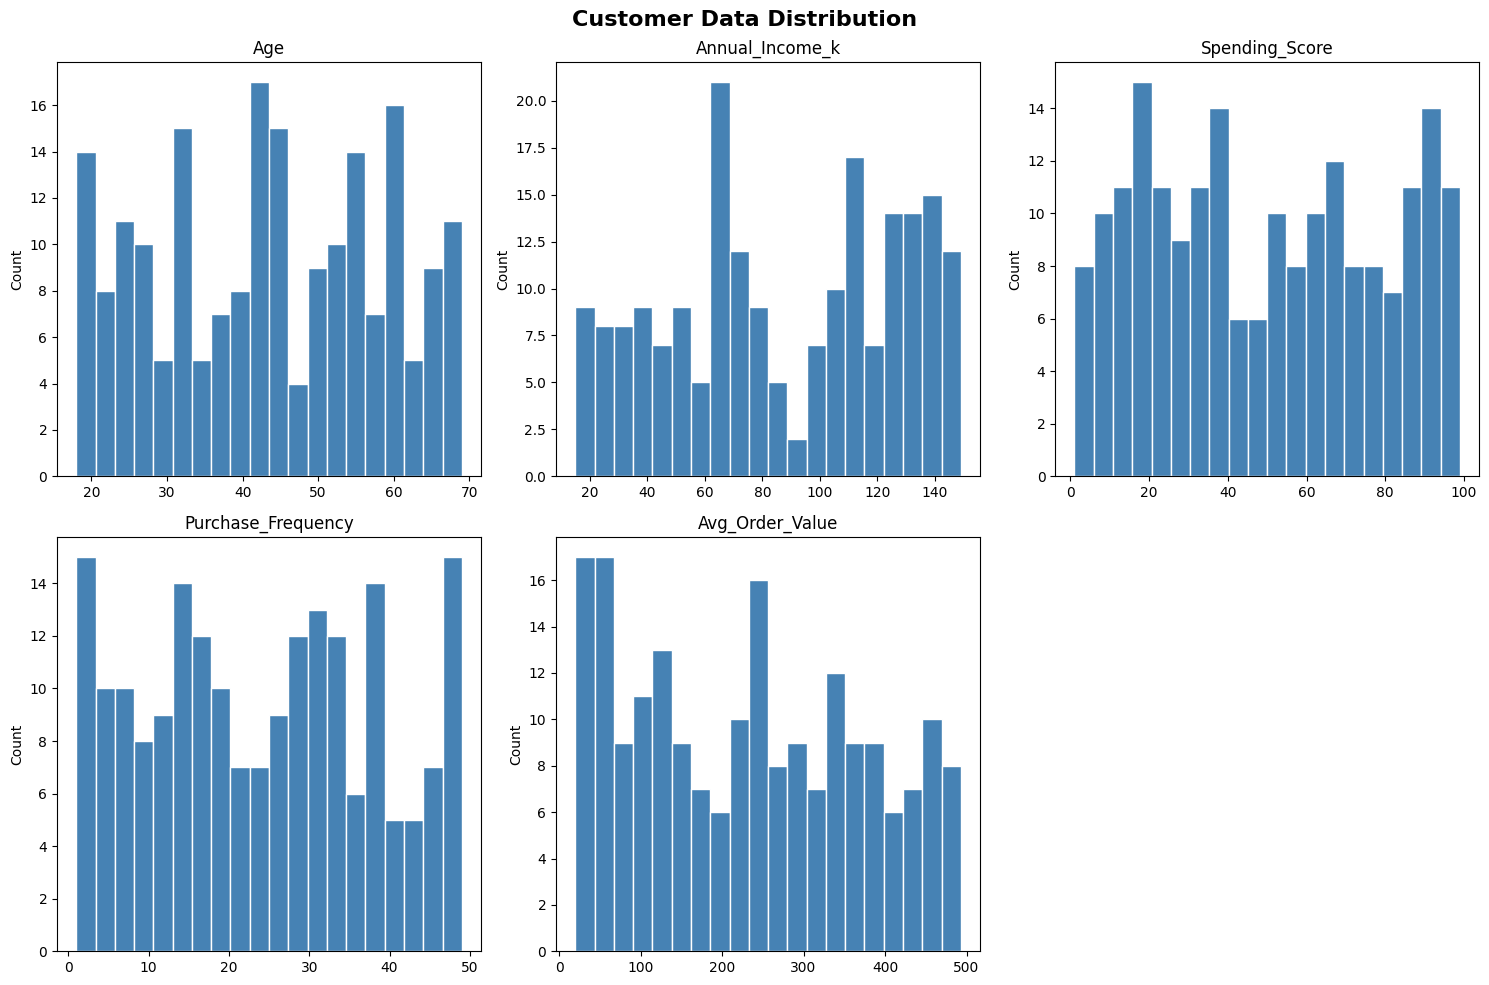

In [12]:
print(df.describe())

cols = ['Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency', 'Avg_Order_Value']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Customer Data Distribution', fontsize=16, fontweight='bold')

for i, col in enumerate(cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')

axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

In [13]:
features = ['Age', 'Annual_Income_k', 'Spending_Score',
            'Purchase_Frequency', 'Avg_Order_Value']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

print("✅ Scaling done! Shape:", X_scaled.shape)

✅ Scaling done! Shape: (200, 5)


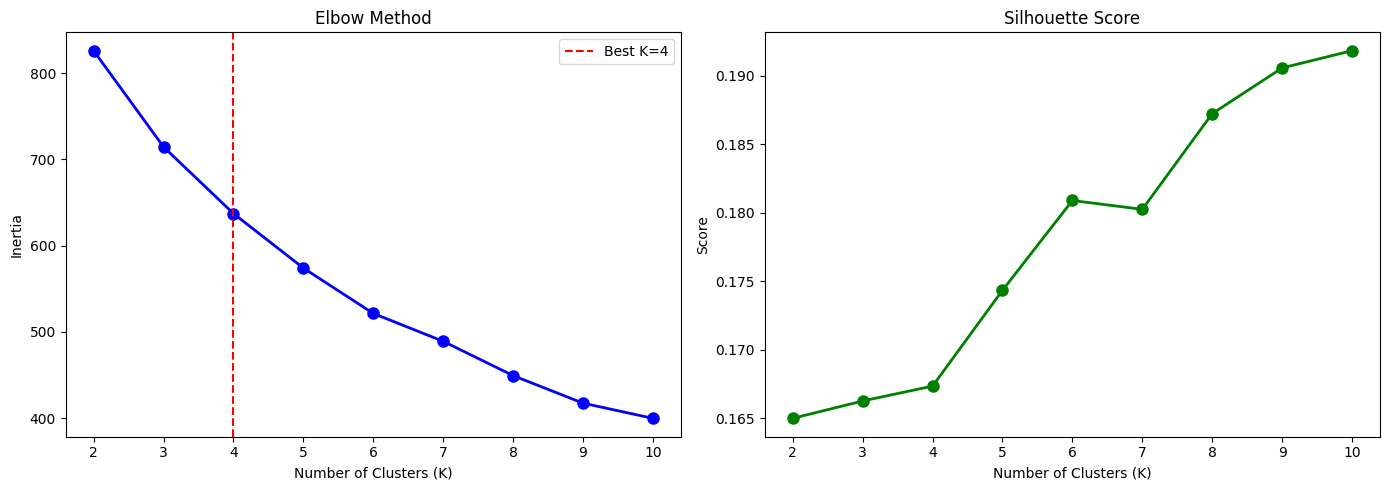

✅ Best K = 4


In [14]:
inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.axvline(x=4, color='red', linestyle='--', label='Best K=4')
ax1.legend()

ax2.plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.show()

print("✅ Best K = 4")

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0: 'Budget Shoppers',
    1: 'High Value Loyalists',
    2: 'Occasional Spenders',
    3: 'Young Explorers'
}
df['Segment'] = df['Cluster'].map(cluster_names)

print("✅ Clustering done!")
print(df['Segment'].value_counts())

✅ Clustering done!
Segment
High Value Loyalists    52
Budget Shoppers         51
Occasional Spenders     49
Young Explorers         48
Name: count, dtype: int64


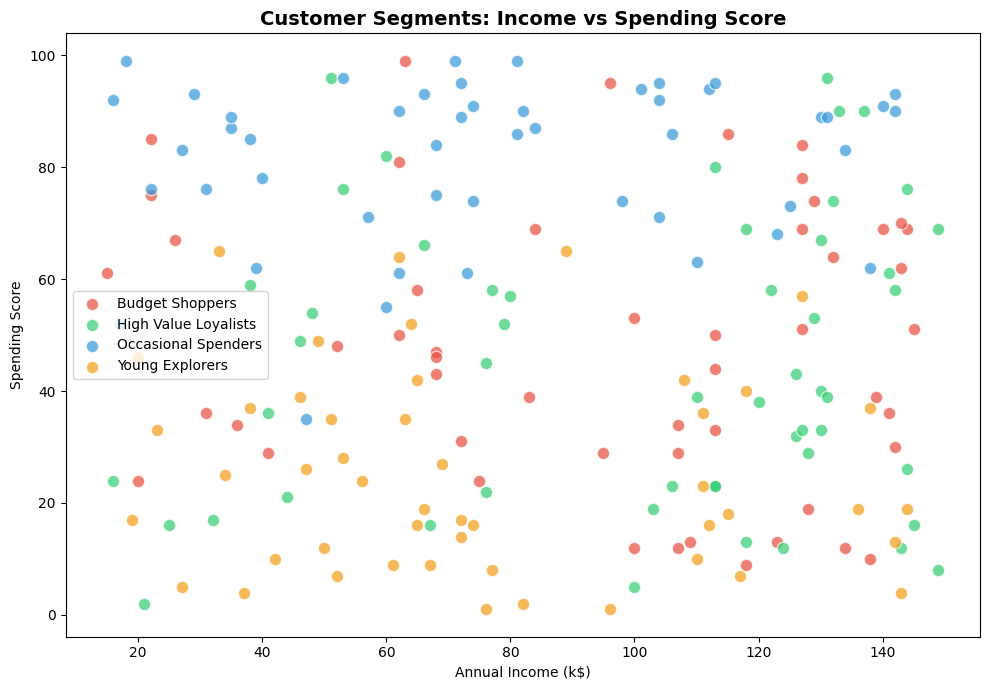

In [16]:
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']

plt.figure(figsize=(10, 7))
for seg, color in zip(cluster_names.values(), colors):
    mask = df['Segment'] == seg
    plt.scatter(df[mask]['Annual_Income_k'], df[mask]['Spending_Score'],
                c=color, label=seg, s=80, alpha=0.7, edgecolors='white')

plt.title('Customer Segments: Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.tight_layout()
plt.show()

📊 Segment Profiles:
                       Age  Annual_Income_k  Spending_Score  \
Segment                                                       
Budget Shoppers       37.0             95.2            47.9   
High Value Loyalists  31.1            100.1            44.1   
Occasional Spenders   55.0             77.8            81.7   
Young Explorers       51.8             75.6            25.0   

                      Purchase_Frequency  Avg_Order_Value  
Segment                                                    
Budget Shoppers                     40.2            209.4  
High Value Loyalists                11.8            138.3  
Occasional Spenders                 22.8            251.4  
Young Explorers                     21.1            341.6  


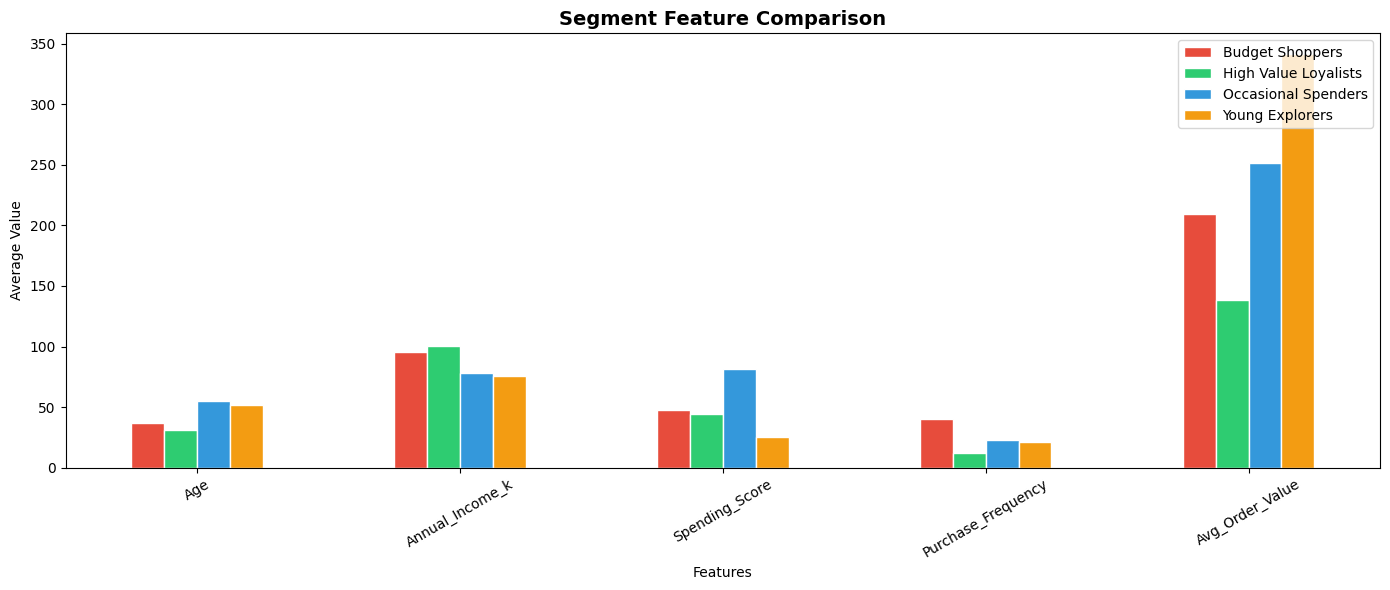

In [17]:
profile = df.groupby('Segment')[features].mean().round(1)
print("📊 Segment Profiles:")
print(profile)

profile.T.plot(kind='bar', figsize=(14, 6), color=colors, edgecolor='white')
plt.title('Segment Feature Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Average Value')
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

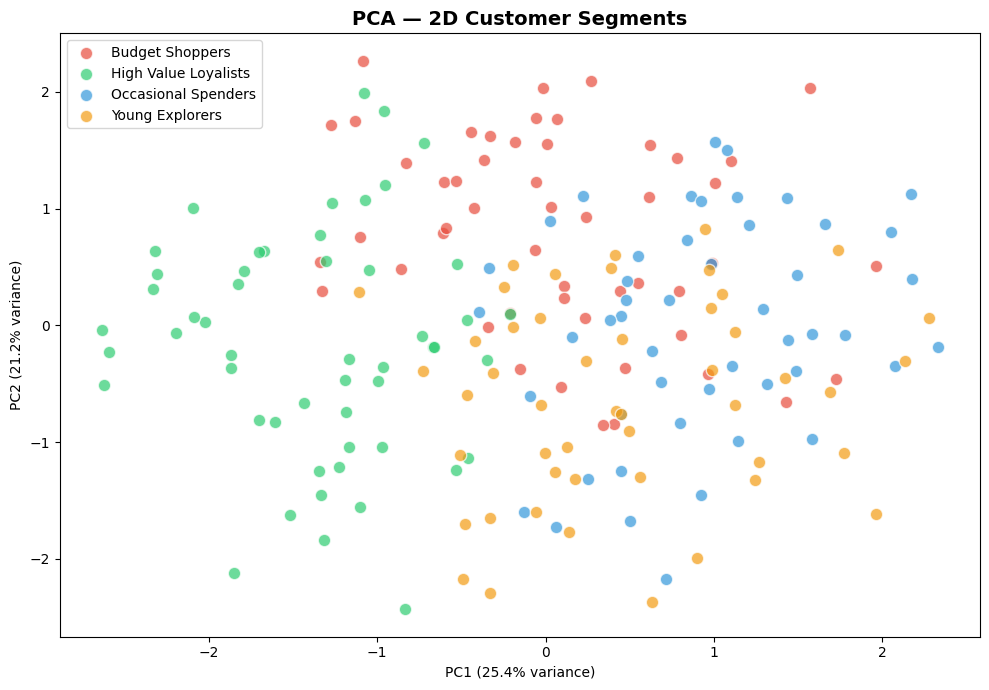

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
for seg, color in zip(cluster_names.values(), colors):
    mask = df['Segment'] == seg
    plt.scatter(df[mask]['PCA1'], df[mask]['PCA2'],
                c=color, label=seg, s=80, alpha=0.7, edgecolors='white')

plt.title('PCA — 2D Customer Segments', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df.to_csv('customer_segments.csv', index=False)

print("=" * 40)
print("✅ PROJECT COMPLETE!")
print("=" * 40)
print(f"Total Customers : 200")
print(f"Total Segments  : 4")
print(f"Features Used   : {features}")
print(f"CSV Saved       : customer_segments.csv")
print("\n📊 Final Segment Counts:")
print(df['Segment'].value_counts())

✅ PROJECT COMPLETE!
Total Customers : 200
Total Segments  : 4
Features Used   : ['Age', 'Annual_Income_k', 'Spending_Score', 'Purchase_Frequency', 'Avg_Order_Value']
CSV Saved       : customer_segments.csv

📊 Final Segment Counts:
Segment
High Value Loyalists    52
Budget Shoppers         51
Occasional Spenders     49
Young Explorers         48
Name: count, dtype: int64
